# FINAL PROJECT

#### Instructions

The final project asks you to analyze and assess the statistical significance of events in scientific data relative to a model. You will do this by following tutorials developed for a nearly identical problem, so that your main task will be to carefully read through these tutorials, copy the parts that you need and modify some code to customize it for your own project.

You will create a Jupyter notebook for this project and, when finished, you will upload your notebook to GitHub and submit the URL to it as the submission to the assignment.

Create a new notebook in your working directory. Copy these instructions as plain text into the first cell. That way you will not have to flip back and forth between your notebook and this page.

1) Download the file hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits from this archive 

### USING SEP TO DETECT OBJECTS IN AN IMAGE AND PERFORM BASIC APERATURE PHOTOMETRY

In [1]:
import numpy as np
import sep

In [2]:
# additional setup for reading the test image and displaying plots
import fitsio
import matplotlib.pyplot as plt
from matplotlib import rcParams

%matplotlib inline

rcParams['figure.figsize'] = [10., 8.]

In [3]:
# read image into standard 2-d numpy array
data = fitsio.read("/Users/juliapenick/ASTR 19/hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits")

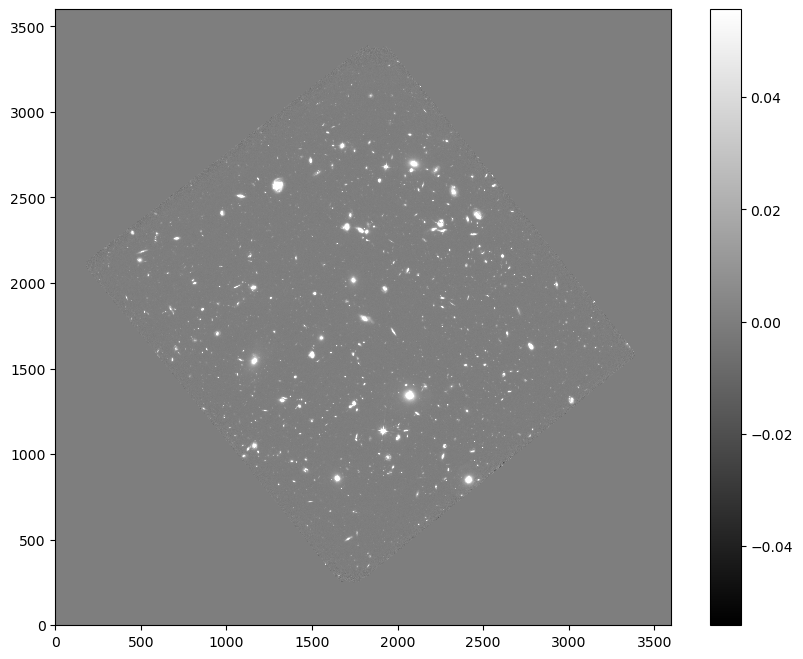

In [4]:
# show the image
m, s = np.mean(data), np.std(data)
plt.imshow(data, interpolation='nearest', cmap='gray', vmin=m-s, vmax=m+s, origin='lower')
plt.colorbar();

### BACKGROUND SUBTRACTION

In [5]:
# measure a spatially varying background on the image
bkg = sep.Background(data)

In [6]:
# get a "global" mean and noise of the image background:
print(bkg.globalback)
print(bkg.globalrms)

0.0
0.0005398219218477607


In [7]:
# evaluate background as 2-d array, same size as original image
bkg_image = bkg.back()
# bkg_image = np.array(bkg) # equivalent to above

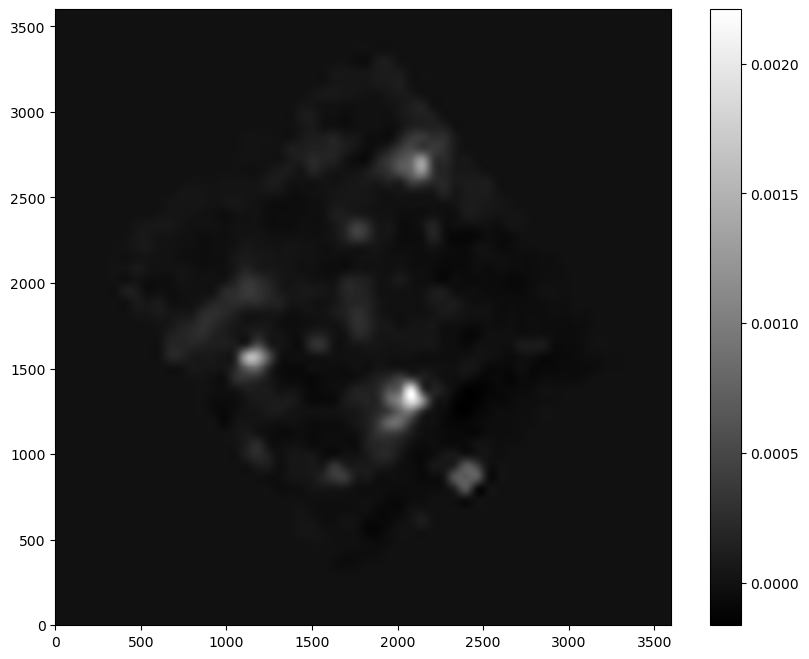

In [8]:
# show the background
plt.imshow(bkg_image, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();

In [9]:
# evaluate the background noise as 2-d array, same size as original image
bkg_rms = bkg.rms()

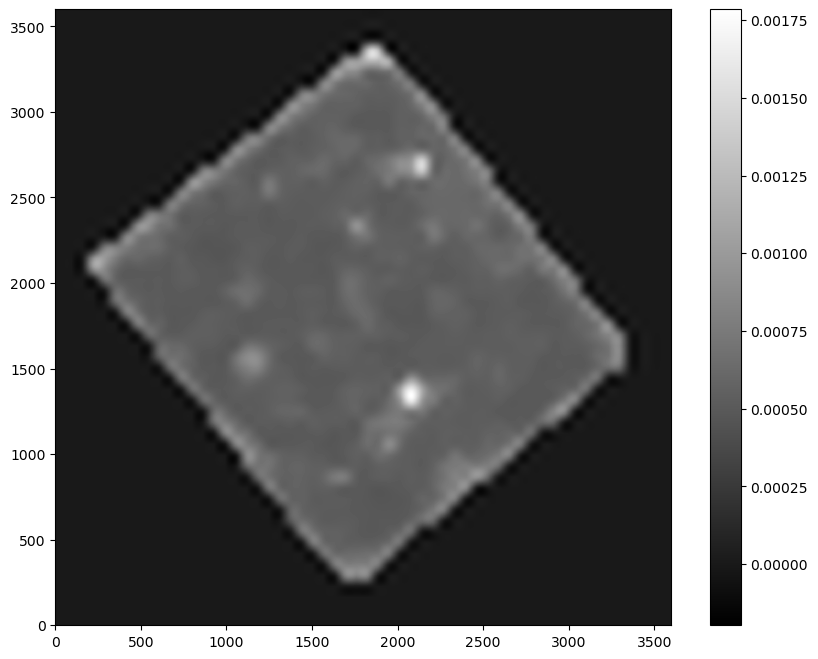

In [10]:
# show the background noise
plt.imshow(bkg_rms, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();

In [11]:
# subtract the background
data_sub = data - bkg

### OBJECT DETECTION

In [12]:
objects = sep.extract(data_sub, 1.5, err=bkg.globalrms)

In [13]:
# how many objects were detected
len(objects)

8640

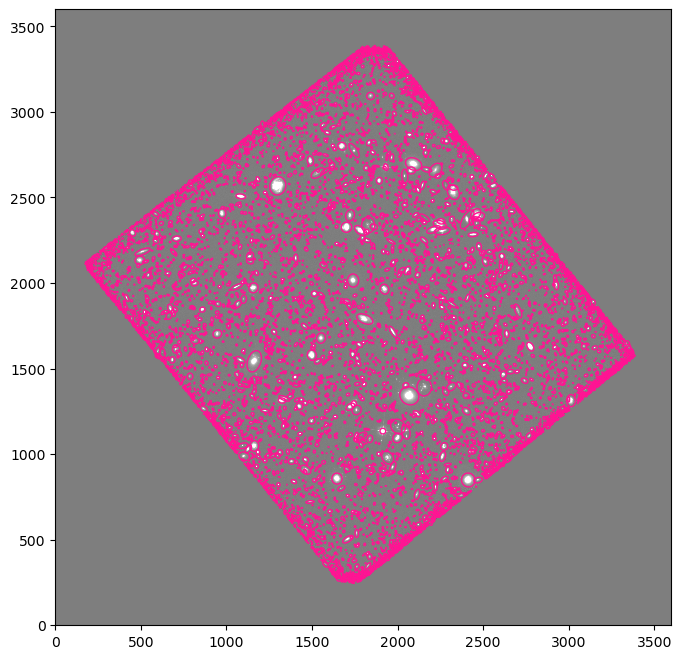

In [14]:
from matplotlib.patches import Ellipse

# plot background-subtracted image
fig, ax = plt.subplots()
m, s = np.mean(data_sub), np.std(data_sub)
im = ax.imshow(data_sub, interpolation='nearest', cmap='gray',
               vmin=m-s, vmax=m+s, origin='lower')

# plot an ellipse for each object
for i in range(len(objects)):
    e = Ellipse(xy=(objects['x'][i], objects['y'][i]),
                width=6*objects['a'][i],
                height=6*objects['b'][i],
                angle=objects['theta'][i] * 180. / np.pi)
    e.set_facecolor('none')
    e.set_edgecolor('deeppink')
    ax.add_artist(e)

In [15]:
# available fields
objects.dtype.names

('thresh',
 'npix',
 'tnpix',
 'xmin',
 'xmax',
 'ymin',
 'ymax',
 'x',
 'y',
 'x2',
 'y2',
 'xy',
 'errx2',
 'erry2',
 'errxy',
 'a',
 'b',
 'theta',
 'cxx',
 'cyy',
 'cxy',
 'cflux',
 'flux',
 'cpeak',
 'peak',
 'xcpeak',
 'ycpeak',
 'xpeak',
 'ypeak',
 'flag')

In [16]:
flux, fluxerr, flag = sep.sum_circle(data_sub, objects['x'], objects['y'],
                                     3.0, err=bkg.globalrms, gain=1.0)

In [17]:
# show the first 10 objects results:
for i in range(10):
    print("object {:d}: flux = {:f} +/- {:f}".format(i, flux[i], fluxerr[i]))

object 0: flux = 0.031282 +/- 0.176890
object 1: flux = 0.031018 +/- 0.176142
object 2: flux = -0.024388 +/- 0.002883
object 3: flux = 0.001947 +/- 0.044219
object 4: flux = 0.012457 +/- 0.111649
object 5: flux = -0.011228 +/- 0.002875
object 6: flux = 0.029368 +/- 0.171394
object 7: flux = -0.009126 +/- 0.002875
object 8: flux = 0.048023 +/- 0.219161
object 9: flux = 0.027840 +/- 0.166877


### 1) NUMBER OF STARS FOUND/HISTOGRAM OF FLUXES

In [18]:
num_sources = len(objects)
print("Number of detected sources:", num_sources)

Number of detected sources: 8640


#### There are 8640 total detected sources (stars) in the dataset. Below are the histograms of their fluxes plotted on a normal scale and also a log scale in attempt to better visualize the data. 

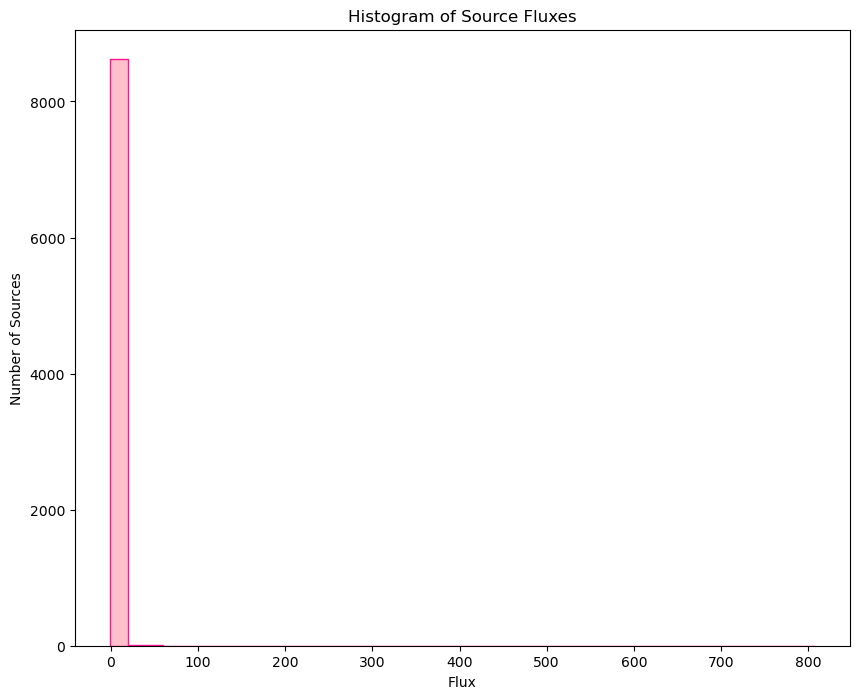

In [19]:
plt.hist(flux, bins=40, color='pink', edgecolor='deeppink')
plt.xlabel("Flux")
plt.ylabel("Number of Sources")
plt.title("Histogram of Source Fluxes")
plt.show()

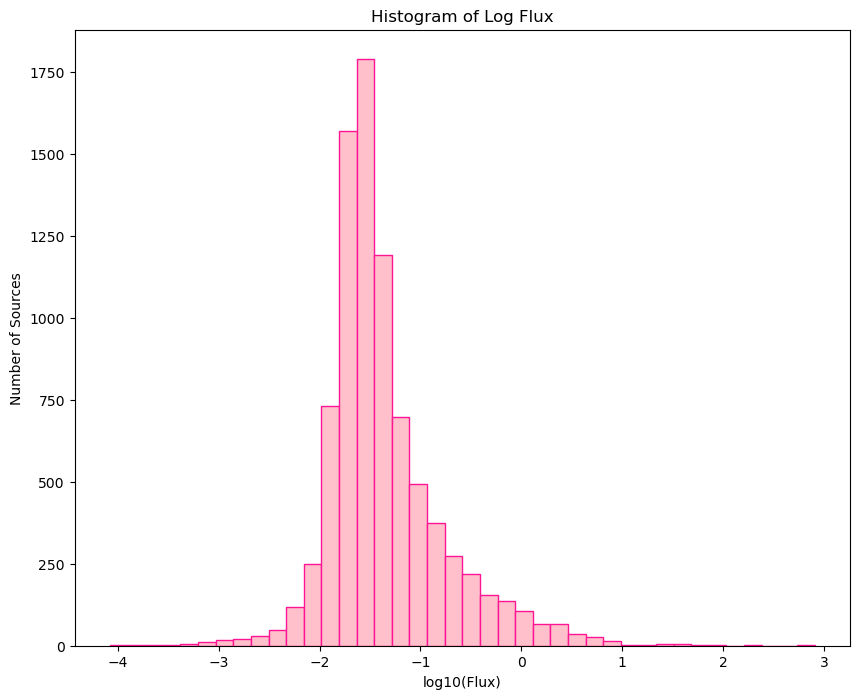

In [20]:
flux_positive = flux[flux > 0]

plt.hist(np.log10(flux_positive), bins=40, color='pink', edgecolor='deeppink')
plt.xlabel("log10(Flux)")
plt.ylabel("Number of Sources")
plt.title("Histogram of Log Flux")
plt.show()

Observation: The flux distribution is highly skewed, with many faint sources and a small number of very bright sources. To better visualize the distribution, the flux values are plotted on a logarithmic scale.

### 2) MEAN, MEDIAN, AND STANDARD DEVIATION

In [21]:
mean_flux = np.mean(flux)
median_flux = np.median(flux)
std_flux = np.std(flux)

print("Mean flux:", mean_flux)
print("Median flux:", median_flux)
print("Standard deviation:", std_flux)

Mean flux: 0.3618620007201894
Median flux: 0.03095655805023853
Standard deviation: 9.243527842777791


#### Results: The mean flux is around 0.361862, the median flux is around 0.030957, and the standard deviation is around 9.243528. 

### 3) LARGEST OUTLIER

In [22]:
max_flux = np.max(flux)
print("Largest Outlier:", max_flux)

Largest Outlier: 807.2972835731507


In [23]:
z_score = (max_flux - mean_flux) / std_flux

print("Distance from mean:", z_score)

Distance from mean: 87.2973431029269


#### Results: The largest outlying flux was found to be 807.29728357 and around 87.297 standard deviations (also referred to as z_score) away from the mean. 